<a href="https://colab.research.google.com/github/iarman04/OIBSIP/blob/main/Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# TASK 5: SALES PREDICTION USING PYTHON
# Track: Data Science | Oasis Infobyte (OIBSIP)
# ==============================================================================

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [3]:
# 1. Dataset Synthesization (Mirroring Advertising.csv structure)
np.random.seed(42)
n_samples = 200

tv = np.random.uniform(10, 300, n_samples)
radio = np.random.uniform(5, 50, n_samples)
newspaper = np.random.uniform(0, 100, n_samples)

In [4]:
# Target variable with domain-realistic coefficients and additive noise
sales = 4.0 + 0.05 * tv + 0.18 * radio + 0.005 * newspaper + np.random.normal(0, 1.2, n_samples)

df_sales = pd.DataFrame({
    'TV': tv,
    'Radio': radio,
    'Newspaper': newspaper,
    'Sales': sales
})

In [5]:
# 2. EDA & Null Check
print("=== Null Value Check ===")
print(df_sales.isnull().sum())

print("\n=== Descriptive Statistics ===")
display(df_sales.describe())

=== Null Value Check ===
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

=== Descriptive Statistics ===


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,150.361808,27.696881,52.067278,16.692470
std,85.518515,13.185054,30.730879,4.912854
min,11.601414,5.227771,1.083765,4.643024
25%,76.288900,16.765813,25.552032,12.566271
50%,153.401013,29.373795,52.539948,16.668134
75%,229.489289,38.398969,81.111489,20.503841
max,296.197212,49.572731,99.971767,25.636228


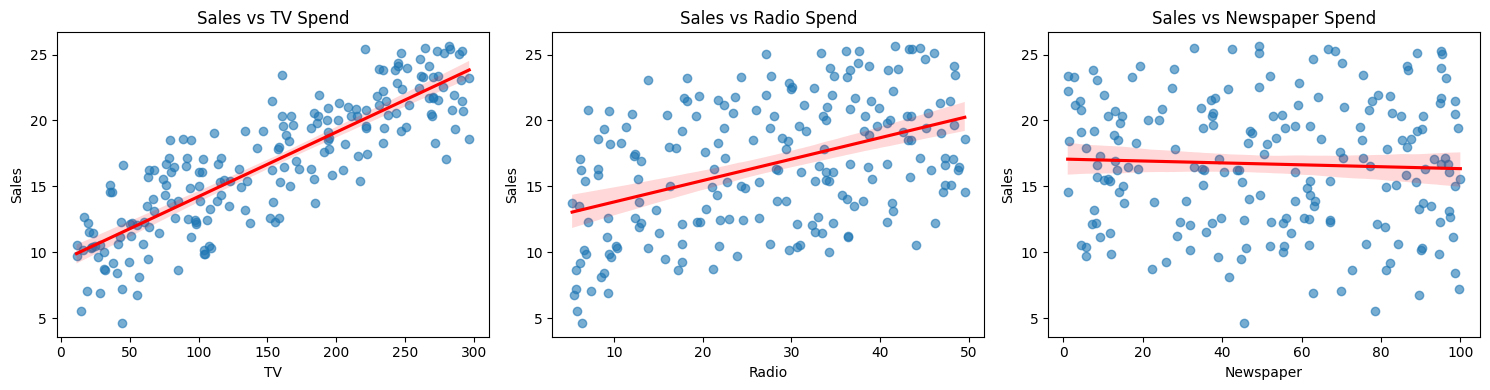

In [6]:
# Scatter plots: Sales vs each media channel
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channels = ['TV', 'Radio', 'Newspaper']

for ax, channel in zip(axes, channels):
    sns.regplot(data=df_sales, x=channel, y='Sales', ax=ax, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
    ax.set_title(f'Sales vs {channel} Spend')

plt.tight_layout()
plt.show()

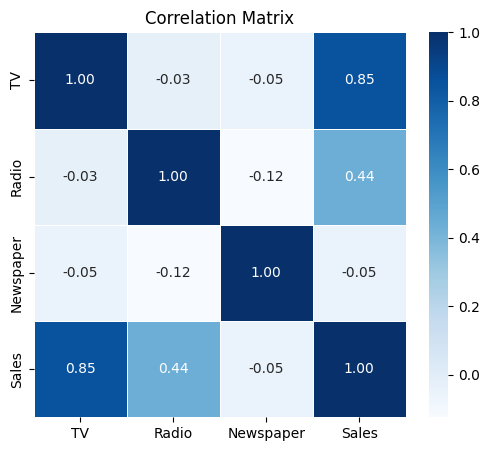

In [7]:
# Correlation matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df_sales.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [8]:
# 3. Model Training & Evaluation
X = df_sales[['TV', 'Radio', 'Newspaper']]
y = df_sales['Sales']

In [10]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

def print_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"=== {model_name} Metrics ===")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}\n")

print_metrics(y_test, lr_preds, "Linear Regression (Baseline)")
print_metrics(y_test, rf_preds, "Random Forest Regressor")

=== Linear Regression (Baseline) Metrics ===
MAE : 0.8458
RMSE: 0.9971
R²  : 0.9588

=== Random Forest Regressor Metrics ===
MAE : 1.0701
RMSE: 1.3678
R²  : 0.9225



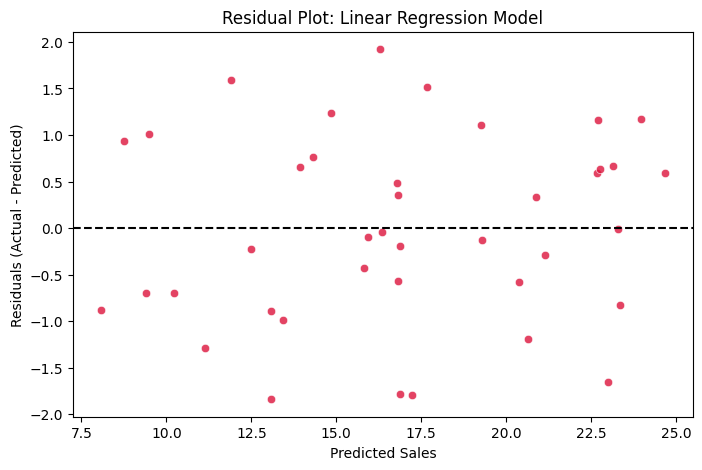

In [11]:
# 4. Residual Plot Analysis
residuals = y_test - lr_preds

plt.figure(figsize=(8, 5))
sns.scatterplot(x=lr_preds, y=residuals, color='crimson', alpha=0.8)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Linear Regression Model')
plt.show()

In [12]:
# 5. Feature Channel Impact
impact_df = pd.DataFrame({
    'Channel': X.columns,
    'Linear Coefficient': lr_model.coef_,
    'RF Feature Importance': rf_model.feature_importances_
})

print("=== Advertising Channel Impact ===")
display(impact_df)

=== Advertising Channel Impact ===


,Channel,Linear Coefficient,RF Feature Importance
0,TV,0.049410,0.762544
1,Radio,0.174743,0.209640
2,Newspaper,0.009571,0.027816


In [15]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=impact_df)

https://docs.google.com/spreadsheets/d/1KXZnyCYW1V_EsglzGFnDuoUMHev7RrlsuIPC3WqtK00/edit#gid=0
